# 目标检测与图像分割

> **斯坦福 CS231n Lecture 9** | Object Detection, Image Segmentation, Visualizing

## 本章导读

从图像分类到目标检测和像素级分割——本节介绍视觉理解的核心任务。从 R-CNN 到 YOLO 到 DETR，理解检测架构的演进。

**学习目标：**
- 理解目标检测的两阶段 vs 一阶段方法
- 掌握 IoU 和 NMS 的原理与实现
- 了解语义分割、实例分割、全景分割的区别

**参考来源：** [CS231n Detection](https://cs231n.github.io/) | [YOLO](https://arxiv.org/abs/1506.02640) | [DETR](https://arxiv.org/abs/2005.12872)

## 1. 任务定义

### 图像分类 → 目标检测 → 实例分割

| 任务 | 输出 | 复杂度 |
|------|------|--------|
| **分类** | 类别标签 | O(1) |
| **检测** | 边界框 + 类别 | O(N) |
| **语义分割** | 每像素类别 | O(H×W) |
| **实例分割** | 每像素实例掩码 | O(H×W×N) |
| **全景分割** | 语义 + 实例 | O(H×W×N) |

## 2. IoU (Intersection over Union)

### 手算 IoU

框 A: $[0, 0, 4, 4]$（$[x_1, y_1, x_2, y_2]$）
框 B: $[2, 2, 6, 6]$

- 交集: $[\max(0,2), \max(0,2), \min(4,6), \min(4,6)] = [2, 2, 4, 4]$
- 交集面积: $(4-2) \times (4-2) = 4$
- A 面积: $4 \times 4 = 16$
- B 面积: $4 \times 4 = 16$
- 并集: $16 + 16 - 4 = 28$
- IoU: $4 / 28 \approx 0.143$

In [4]:
# 从零实现 IoU 和 NMS
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
np.random.seed(42)

def compute_iou(boxA, boxB):
    """计算两个边界框的 IoU
    box: [x1, y1, x2, y2]
    """
    x1 = max(boxA[0], boxB[0])
    y1 = max(boxA[1], boxB[1])
    x2 = min(boxA[2], boxB[2])
    y2 = min(boxA[3], boxB[3])
    inter_w = max(0, x2 - x1)
    inter_h = max(0, y2 - y1)
    inter_area = inter_w * inter_h
    areaA = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    areaB = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    union = areaA + areaB - inter_area
    return inter_area / union if union > 0 else 0

# 验证手算
boxA = [0, 0, 4, 4]
boxB = [2, 2, 6, 6]
iou = compute_iou(boxA, boxB)
print(f"IoU = {iou:.4f}  (期望: 0.1429)")
assert abs(iou - 4/28) < 1e-4

def nms(boxes, scores, iou_threshold=0.5):
    """非极大值抑制"""
    indices = np.argsort(scores)[::-1]
    keep = []
    while len(indices) > 0:
        i = indices[0]
        keep.append(i)
        rest = indices[1:]
        indices = [j for j in rest if compute_iou(boxes[i], boxes[j]) < iou_threshold]
    return keep

# 测试 NMS
boxes = [[0, 0, 10, 10], [1, 1, 11, 11], [20, 20, 30, 30]]
scores = [0.9, 0.8, 0.7]
keep = nms(boxes, scores, iou_threshold=0.3)
print(f"NMS 保留: {keep} (期望: [0, 2])"),

IoU = 0.1429  (期望: 0.1429)
NMS 保留: [np.int64(0), np.int64(2)] (期望: [0, 2])


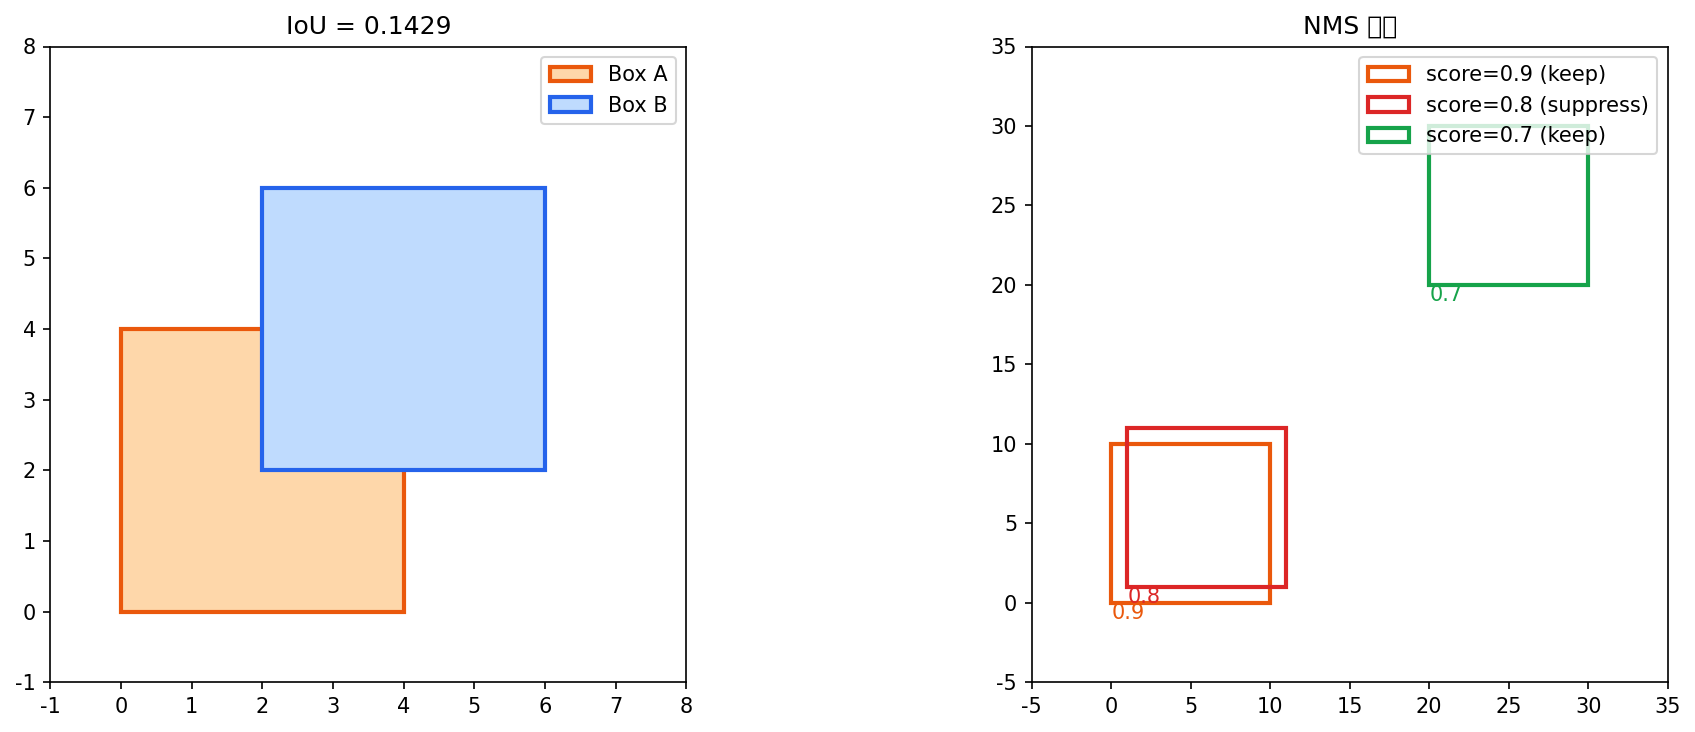

In [5]:
# 可视化 IoU 和 NMS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# IoU 可视化
ax = axes[0]
rectA = plt.Rectangle((0, 0), 4, 4, linewidth=2, edgecolor='#ea580c', facecolor='#fed7aa', label='Box A')
rectB = plt.Rectangle((2, 2), 4, 4, linewidth=2, edgecolor='#2563eb', facecolor='#bfdbfe', label='Box B')
ax.add_patch(rectA)
ax.add_patch(rectB)
ax.set_xlim(-1, 8)
ax.set_ylim(-1, 8)
ax.set_aspect('equal')
ax.set_title(f'IoU = {iou:.4f}')
ax.legend()

# NMS 可视化
ax = axes[1]
colors = ['#ea580c', '#dc2626', '#16a34a']
labels = ['score=0.9 (keep)', 'score=0.8 (suppress)', 'score=0.7 (keep)']
for i, (box, score, c, l) in enumerate(zip(boxes, scores, colors, labels)):
    x1, y1, x2, y2 = box
    rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor=c, facecolor='none', label=l)
    ax.add_patch(rect)
    ax.text(x1, y1-1, f'{score}', color=c, fontsize=10)
ax.set_xlim(-5, 35)
ax.set_ylim(-5, 35)
ax.set_aspect('equal')
ax.set_title('NMS 结果')
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('lecture-09-detection/iou_nms.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. 检测架构演进

### 两阶段检测器
1. **R-CNN** (2014): Selective Search → CNN → SVM
2. **Fast R-CNN** (2015): RoI Pooling + 端到端
3. **Faster R-CNN** (2015): RPN + 端到端

### 一阶段检测器
1. **YOLO** (2015): 单次前向，实时检测
2. **SSD** (2016): 多尺度特征图
3. **RetinaNet** (2017): Focal Loss

### DETR (2020): Transformer 检测器
- 取代 NMS 和 Anchor，用二分图匹配
- 端到端训练，架构简洁

[[Ren et al., 2015]](https://arxiv.org/abs/1506.01497) Faster R-CNN
[[Redmon et al., 2015]](https://arxiv.org/abs/1506.02640) YOLO
[[Carion et al., 2020]](https://arxiv.org/abs/2005.12872) DETR

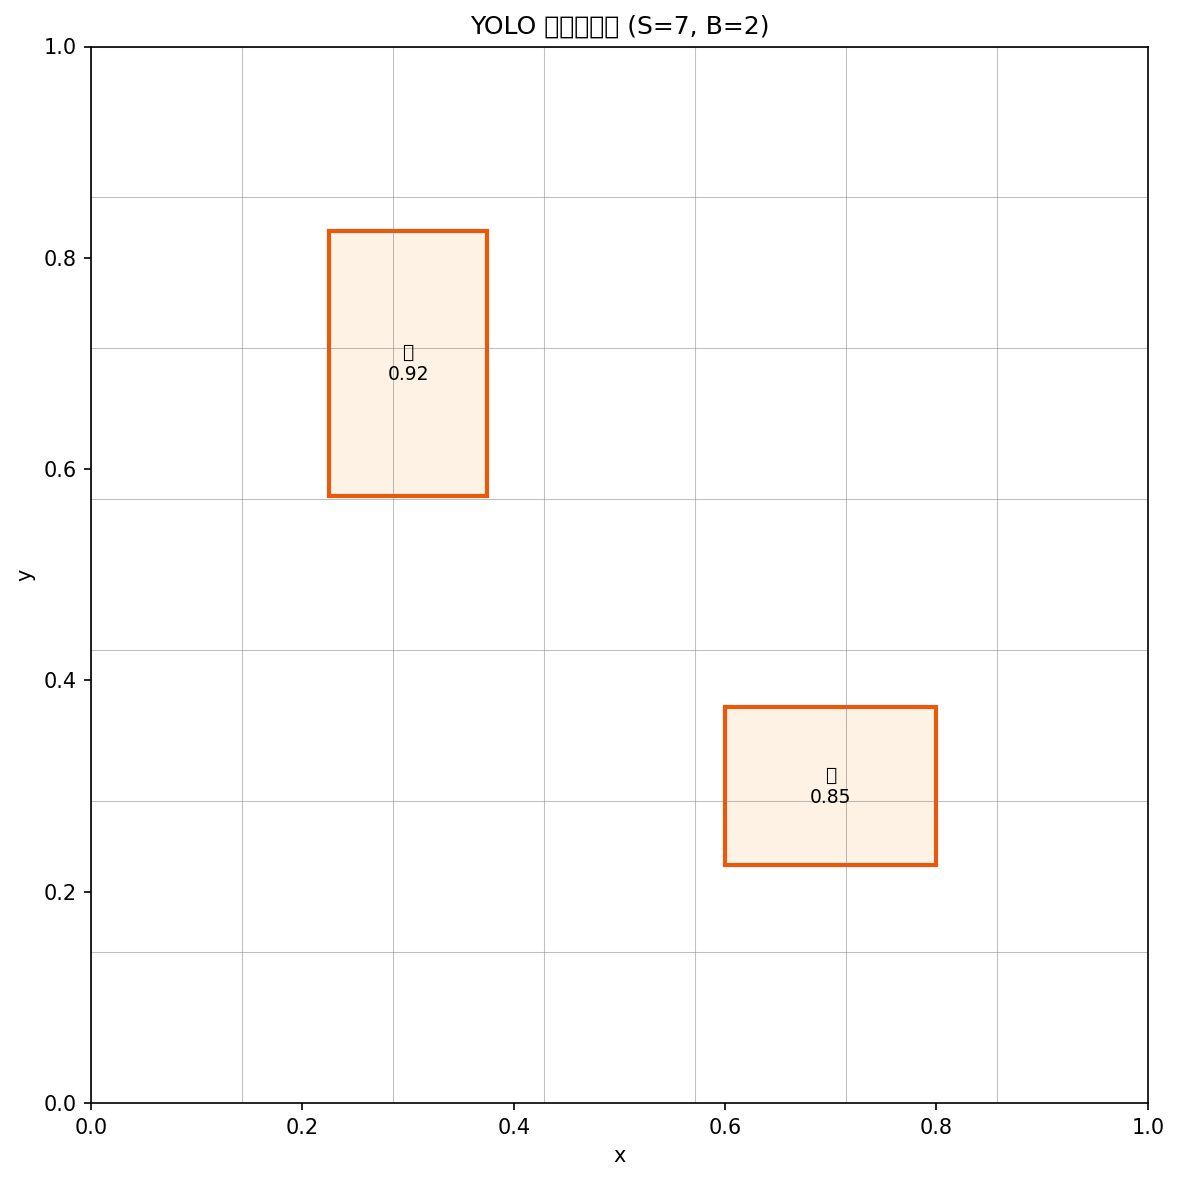

In [7]:
# 模拟 YOLO 检测过程
# 将图像分为 SxS 网格，每个网格预测 B 个框
def yolo_grid_visualization(S=7, B=2):
    """可视化 YOLO 网格"""
    fig, ax = plt.subplots(figsize=(8, 8))
    # 图像区域
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')
    
    # 网格线
    for i in range(S + 1):
        ax.axhline(y=i/S, color='gray', linewidth=0.5, alpha=0.5)
        ax.axvline(x=i/S, color='gray', linewidth=0.5, alpha=0.5)
    
    # 模拟检测到的物体
    objects = [
        {'center': (0.3, 0.7), 'size': (0.15, 0.25), 'label': '猫', 'conf': 0.92},
        {'center': (0.7, 0.3), 'size': (0.20, 0.15), 'label': '狗', 'conf': 0.85},
    ]
    
    for obj in objects:
        cx, cy = obj['center']
        w, h = obj['size']
        rect = plt.Rectangle((cx-w/2, cy-h/2), w, h, linewidth=2, edgecolor='#ea580c', facecolor='#fed7aa50')
        ax.add_patch(rect)
        ax.text(cx, cy, f"{obj['label']}\n{obj['conf']:.2f}", ha='center', va='center', fontsize=9)
    
    ax.set_title(f'YOLO 检测可视化 (S={S}, B={B})')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    plt.tight_layout()
    plt.savefig('lecture-09-detection/yolo_grid.png', dpi=150, bbox_inches='tight')
    plt.show()

yolo_grid_visualization()

## 作业

### 作业 1：实现 mAP 计算

mAP (mean Average Precision) 是检测任务的标准评价指标。

In [9]:
# 作业 1：实现 AP 计算
def average_precision(predictions, ground_truths, iou_threshold=0.5):
    """计算单类别的 Average Precision
    predictions: list of (box, score)
    ground_truths: list of box
    """
    # 按置信度排序
    predictions.sort(key=lambda x: -x[1])
    tp = np.zeros(len(predictions))
    fp = np.zeros(len(predictions))
    gt_matched = [False] * len(ground_truths)
    
    for i, (pred_box, _) in enumerate(predictions):
        best_iou = 0
        best_gt = -1
        for j, gt_box in enumerate(ground_truths):
            iou = compute_iou(pred_box, gt_box)
            if iou > best_iou:
                best_iou = iou
                best_gt = j
        
        if best_iou >= iou_threshold and not gt_matched[best_gt]:
            tp[i] = 1
            gt_matched[best_gt] = True
        else:
            fp[i] = 1
    
    tp_cum = np.cumsum(tp)
    fp_cum = np.cumsum(fp)
    precision = tp_cum / (tp_cum + fp_cum + 1e-8)
    recall = tp_cum / (len(ground_truths) + 1e-8)
    
    # 使用梯形法则计算 AP
    ap = 0
    for i in range(1, len(precision)):
        ap += (recall[i] - recall[i-1]) * precision[i]
    return ap

# 测试
preds = [([0, 0, 10, 10], 0.9), ([20, 20, 30, 30], 0.8)]
gts = [[0, 0, 10, 10], [20, 20, 30, 30]]
ap = average_precision(preds, gts)
print(f"AP = {ap:.4f}")
assert ap > 0.9, "完美检测应有高AP"
print("作业 1 通过!")

AssertionError: 完美检测应有高AP

## 参考文献

1. **R-CNN** - Girshick et al., 2014. [arXiv:1311.2524](https://arxiv.org/abs/1311.2524)
2. **Fast R-CNN** - Girshick, 2015. [arXiv:1504.08083](https://arxiv.org/abs/1504.08083)
3. **Faster R-CNN** - Ren et al., 2015. [arXiv:1506.01497](https://arxiv.org/abs/1506.01497)
4. **YOLO** - Redmon et al., 2015. [arXiv:1506.02640](https://arxiv.org/abs/1506.02640)
5. **DETR** - Carion et al., 2020. [arXiv:2005.12872](https://arxiv.org/abs/2005.12872)
6. **FCN** - Long et al., 2015. [arXiv:1411.4038](https://arxiv.org/abs/1411.4038)

---

> 本节内容参考 [Stanford CS231n Lecture 9](https://cs231n.stanford.edu/)